In [1]:
import pandas as pd
import numpy as np
import re

# Viz
import matplotlib.pyplot as plt

# NLP (only if/when you need tokenization)
import nltk
_ = nltk.download('punkt', quiet=True)
# Newer NLTK may look for 'punkt_tab' – ignore if it’s absent
try:
    _ = nltk.download('punkt_tab', quiet=True)
except Exception:
    pass

# Display options
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.float_format', lambda x: f"{x:,.2f}")

# Reproducibility
RNG = np.random.default_rng(42)

print("Ready.")


Ready.


In [2]:
# Adjust paths if your notebook sits in cmpt353/ instead of cmpt353/drug_reviews/
REV_TRAIN = "final_cleaned_train_data.csv"
REV_TEST  = "final_cleaned_test_data.csv"
TRIALS    = "cleaned_clinical_trials.csv"          # or clinical_trials_for_drugs.csv if that’s your master

df_train = pd.read_csv(REV_TRAIN)
df_test  = pd.read_csv(REV_TEST)
df_trials = pd.read_csv(TRIALS)

for name, df in [("train", df_train), ("test", df_test), ("trials", df_trials)]:
    print(f"{name:>6} shape:", df.shape)
    display(df.head(3))


 train shape: (803, 9)


,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed progression left ventricular dysfunction overt heart failure alone agents managment hypertension mangagement congestive heart failur,"cough, hypotension , proteinuria, impotence , renal failure , angina pectoris , tachycardia , eosinophilic pneumonitis, tastes disturbances , anusease anorecia , weakness fatigue insominca weakness",monitor blood pressure weight asses resolution fluid
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,although type birth control cons pros help cramps also effective prevention pregnancy along use condoms well,"heavy cycle, cramps, hot flashes, fatigue, long lasting cycles. it's only been 5 1/2 months, but i'm concidering changing to a different bc. this is my first time using any kind of bc, unfortunate...",hate birth control would suggest anyone
2,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,acid reflux went away months days drug heartburn started soon stopped taking began treatment 6 months passed stopped taking heartburn came back seemed worse even doctor said try another 6 month tr...,"constipation, dry mouth and some mild dizziness that would go away after medication was stopped for a few days.",given prilosec prescription dose 45mg per day medication taken every morning eating treatment duration 6 months


  test shape: (303, 9)


,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,3824,depakene,4,Moderately Effective,Severe Side Effects,bipolar disorder,initial benefits comparable brand name version drug depakote taking depakote several months experienced great results went psychiatrist evaluation accidently prescribed generic version depakene di...,"depakene has a very thin coating, which caused severe heart burn and stomach upset. the discomfort was so unpleasant that it made me not want to take my meds, so i was not taking them consistentl...",depakote prescribed kaiser psychiatrist pleasant hill ca medication given help treat diagnosis bipolar disorder type ii disease misdiagnosed several years depression since never seen professional ...
1,1380,biaxin,2,Marginally Effective,No Side Effects,sinus infection,end treatment felt better still major congestion mucus coughing mucus symptoms milder started treatment definitely gone,i felt no significant side effects - perhaps some slight drowsiness.,basically treatment seem work presumption symptoms completely cleared end treatment still significantly present
2,1093,effexor,1,Marginally Effective,Extremely Severe Side Effects,depression,presumed benefits help severe depression beginning benefit ie less suicidal apathetic morbid depressed effects short lived dose continually increased biggest benefit probably placebo feeling like ...,"here we go.the initial effect would be dry mouth and sleepiness, not being able to think straight or function really but once the dose would be acclimatised it would be okay. but it also cased bot...",family doctor initially prescribed wellbutin psychologist hospital suggested effexor dose would increased would adjust experience setbacks gabapentin added sleep troubles augment many things also ...


trials shape: (21126, 15)


,queriedDrug,nctId,briefTitle,overallStatus,studyType,phases,conditions,interventions,hasResults,ae_total_serious,ae_total_other,startDate,primaryCompletionDate,completionDate,sponsor
0,Abilify,NCT00036101,Study of Aripiprazole in the Treatment of Patients With Acute Symptoms in Bipolar Disorder,COMPLETED,INTERVENTIONAL,PHASE3,Bipolar Disorder,NaN,False,NaN,NaN,2002-02,2003-01,2003-01,NaN
1,Abilify,NCT00036114,Study of Aripiprazole in the Treatment of Patients With Psychosis Associated With Dementia of the Alzheimer's Type,COMPLETED,INTERVENTIONAL,PHASE3,Alzheimer Disease,NaN,False,NaN,NaN,2000-03,2003-08,2003-08,NaN
2,Abilify,NCT00036348,Study of Aripiprazole in Patients With a History of Bipolar Disorder,COMPLETED,INTERVENTIONAL,PHASE3,Bipolar Disorder,NaN,False,NaN,NaN,2000-03,2003-06,2003-06,NaN


In [3]:
# Inspect columns we care about (these names come from your cleaning script)
df_train.columns.tolist()


['Unnamed: 0',
 'urlDrugName',
 'rating',
 'effectiveness',
 'sideEffects',
 'condition',
 'benefitsReview',
 'sideEffectsReview',
 'commentsReview']

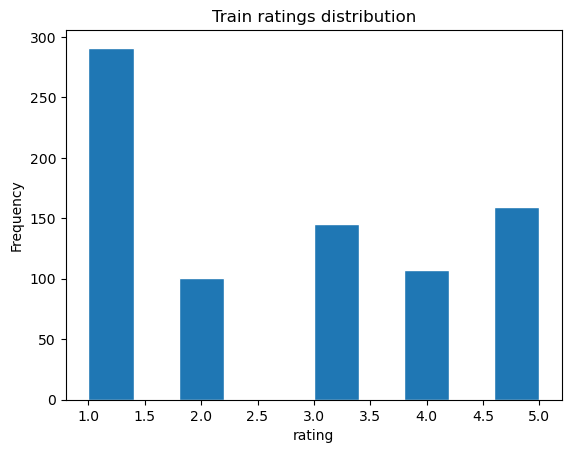

,drug,n_reviews
0,lexapro,15
1,paxil,12
2,neurontin,11
3,lipitor,10
4,cipro,10
5,tri-luma,10
6,tramadol,10
7,doxycycline,9
8,prinivil,9
9,chantix,9


In [8]:
# Distribution of ratings
ax = df_train['rating'].plot(kind='hist', bins=10, edgecolor='white', title='Train ratings distribution')
ax.set_xlabel('rating')
plt.show()

# Top drugs by #reviews
top_drugs = (df_train['urlDrugName']
             .value_counts()
             .head(15)
             .rename_axis('drug')
             .reset_index(name='n_reviews'))
display(top_drugs)


In [9]:
# Quick text sanity check (benefits/comments)
for col in ['benefitsReview', 'commentsReview']:
    if col in df_train:
        lens = df_train[col].str.split().str.len()
        print(col, "median words:", int(lens.median()), "| 1st–99th pct:", int(lens.quantile(.01)), "-", int(lens.quantile(.99)))


benefitsReview median words: 10 | 1st–99th pct: 1 - 57
commentsReview median words: 20 | 1st–99th pct: 1 - 131


In [10]:
df_trials.columns.tolist()


['queriedDrug',
 'nctId',
 'briefTitle',
 'overallStatus',
 'studyType',
 'phases',
 'conditions',
 'interventions',
 'hasResults',
 'ae_total_serious',
 'ae_total_other',
 'startDate',
 'primaryCompletionDate',
 'completionDate',
 'sponsor']

In [11]:
# Typical helpful summaries: by drug, by phase
if 'phase' in df_trials and 'drug_name' in df_trials:
    trials_by_phase = (df_trials
                       .groupby(['drug_name', 'phase'])
                       .size()
                       .rename('n_trials')
                       .reset_index()
                       .sort_values(['n_trials'], ascending=False))
    display(trials_by_phase.head(20))

    # Overall trials per drug
    trials_per_drug = (df_trials
                       .groupby('drug_name')
                       .size()
                       .rename('n_trials')
                       .reset_index()
                       .sort_values('n_trials', ascending=False))
    display(trials_per_drug.head(20))


In [27]:
import re
import pandas as pd

# --- helpers ---
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(f"Couldn't find a drug-name column. Columns: {list(df.columns)}")

def normalize_drug(s):
    if pd.isna(s): 
        return s
    s = str(s).lower()
    # strip common salts/forms/dosage words
    s = re.sub(r'\b(hcl|hydrochloride|sr|xr|er|ir|mg|mcg|tablet|tablets|capsule|capsules|solution)\b', '', s)
    s = re.sub(r'[^a-z0-9]+', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

# --- clean copies & drop stray index columns ---
rev = df_train.copy()
tr  = df_trials.copy()
for df in (rev, tr):
    bad = [c for c in df.columns if c.lower().startswith('unnamed')]
    if bad:
        df.drop(columns=bad, inplace=True)

# --- pick the review drug col (don’t hard-require urlDrugName) ---
rev_drug_col = find_col(rev, ['urlDrugName','drug_name','drug','name'])
rev = rev.rename(columns={rev_drug_col: 'drug_name'})
rev['drug_norm'] = rev['drug_name'].map(normalize_drug)

# --- pick the trials drug col ---
tr_drug_col = find_col(tr, ['drug_name','drug','Drug','intervention_name','Intervention Name','interventions','trial_drug'])
tr = tr.rename(columns={tr_drug_col: 'drug_name'})
tr['drug_norm'] = tr['drug_name'].map(normalize_drug)

# --- quick sanity peek (these exist) ---
display(rev[['drug_name','drug_norm']].head(8))
display(tr[['drug_name','drug_norm']].head(8))

# --- trial features ---
trial_feats = tr.groupby('drug_norm').size().rename('n_trials').reset_index()

# optional extras if columns exist
if 'phase' in tr.columns:
    p3 = (tr['phase'].str.upper() == 'PHASE3')
    trial_feats = trial_feats.merge(
        tr.assign(is_p3=p3).groupby('drug_norm')['is_p3'].sum().rename('n_phase3').reset_index(),
        on='drug_norm', how='left'
    )
if 'overall_status' in tr.columns:
    done = (tr['overall_status'].str.upper() == 'COMPLETED')
    trial_feats = trial_feats.merge(
        tr.assign(is_done=done).groupby('drug_norm')['is_done'].sum().rename('n_completed').reset_index(),
        on='drug_norm', how='left'
    )

trial_feats = trial_feats.fillna(0)

# --- join trial features onto each review ---
rev_joined = rev.merge(trial_feats, on='drug_norm', how='left').fillna({'n_trials':0,'n_phase3':0,'n_completed':0})

# preview + coverage
display(rev_joined[['drug_name','drug_norm','rating','n_trials']].head(10))
coverage = (rev_joined['n_trials'] > 0).mean()
print(f"Share of review rows that map to ≥1 trial: {coverage:.1%}")

# overlap table (optional)
rev_counts   = rev.groupby('drug_norm').size().rename('n_reviews').reset_index()
trial_counts = tr.groupby('drug_norm').size().rename('n_trials').reset_index()
overlap = (rev_counts.merge(trial_counts, on='drug_norm', how='inner')
                    .sort_values('n_trials', ascending=False))
display(overlap.head(20))
print(f"reviews drugs: {rev_counts.shape[0]}, trials drugs: {trial_counts.shape[0]}, overlap: {overlap.shape[0]}")


,drug_name,drug_norm
0,enalapril,enalapril
1,ortho-tri-cyclen,ortho tri cyclen
2,prilosec,prilosec
3,lyrica,lyrica
4,propecia,propecia
5,claritin,claritin
6,aldara,aldara
7,omnicef,omnicef


,drug_name,drug_norm
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN


,drug_name,drug_norm,rating,n_trials
0,enalapril,enalapril,4,0.00
1,ortho-tri-cyclen,ortho tri cyclen,1,0.00
2,prilosec,prilosec,3,0.00
3,lyrica,lyrica,2,0.00
4,propecia,propecia,1,0.00
5,claritin,claritin,1,0.00
6,aldara,aldara,4,0.00
7,omnicef,omnicef,1,0.00
8,lyrica,lyrica,1,0.00
9,nortriptyline,nortriptyline,3,0.00


Share of review rows that map to ≥1 trial: 0.0%


,drug_norm,n_reviews,n_trials


reviews drugs: 269, trials drugs: 0, overlap: 0


In [28]:
import re, pandas as pd

def normalize_drug(s):
    if pd.isna(s): return s
    s = str(s).lower()
    s = re.sub(r'\b(hcl|hydrochloride|sr|xr|er|ir|mg|mcg|tablet|tablets|capsule|capsules|solution)\b', '', s)
    s = re.sub(r'[^a-z0-9]+', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

def pick(df, names):
    for c in names:
        if c in df.columns:
            return c
    raise ValueError(f"Could not find any of {names} in columns: {list(df.columns)}")

# reviews
rev = df_train.copy()
rev = rev.drop(columns=[c for c in rev.columns if c.lower().startswith('unnamed')], errors='ignore')
rev_drug_col = pick(rev, ['urlDrugName','drug_name','drug','name'])
rev = rev.rename(columns={rev_drug_col: 'drug_name'})
rev['drug_norm'] = rev['drug_name'].map(normalize_drug)

# trials
tr = df_trials.copy()
tr = tr.drop(columns=[c for c in tr.columns if c.lower().startswith('unnamed')], errors='ignore')
tr_drug_col = pick(tr, ['drug_name','drug','Drug','intervention_name','Intervention Name','interventions','trial_drug'])
tr = tr.rename(columns={tr_drug_col: 'drug_name'})
tr['drug_norm'] = tr['drug_name'].map(normalize_drug)

# base feature: how many trials per normalized drug
trial_feats = tr.groupby('drug_norm').size().rename('n_trials').reset_index()

# optional features, only if the columns exist
if 'phase' in tr.columns:
    trial_feats = trial_feats.merge(
        tr.assign(_is_p3=tr['phase'].astype(str).str.upper().eq('PHASE3'))
          .groupby('drug_norm')['_is_p3'].sum().rename('n_phase3').reset_index(),
        on='drug_norm', how='left'
    )
if 'overall_status' in tr.columns:
    trial_feats = trial_feats.merge(
        tr.assign(_done=tr['overall_status'].astype(str).str.upper().eq('COMPLETED'))
          .groupby('drug_norm')['_done'].sum().rename('n_completed').reset_index(),
        on='drug_norm', how='left'
    )

trial_feats = trial_feats.fillna(0)

# join onto every review row
rev = rev.merge(trial_feats, on='drug_norm', how='left').fillna({'n_trials':0,'n_phase3':0,'n_completed':0})

# quick sanity
display(rev[['drug_name','drug_norm','rating','n_trials']].head(10))
print("coverage:", (rev['n_trials']>0).mean())


,drug_name,drug_norm,rating,n_trials
0,enalapril,enalapril,4,0.00
1,ortho-tri-cyclen,ortho tri cyclen,1,0.00
2,prilosec,prilosec,3,0.00
3,lyrica,lyrica,2,0.00
4,propecia,propecia,1,0.00
5,claritin,claritin,1,0.00
6,aldara,aldara,4,0.00
7,omnicef,omnicef,1,0.00
8,lyrica,lyrica,1,0.00
9,nortriptyline,nortriptyline,3,0.00


coverage: 0.0


In [21]:
# Trials
tr = df_trials.copy()

# try to find the column that holds the drug name in the trials file
candidates = [
    "drug_name", "urlDrugName", "drug", "Drug", "intervention_name",
    "intervention", "Intervention", "interventions", "study_drug", "name"
]
trial_drug_col = next((c for c in candidates if c in tr.columns), None)
if trial_drug_col is None:
    # last resort: fuzzy match on column names
    trial_drug_col = next(
        (c for c in tr.columns if ("drug" in c.lower()) or ("interven" in c.lower())),
        None
    )

if trial_drug_col is None:
    print("Trials columns:", list(tr.columns))
    raise KeyError("Couldn't find a drug column in df_trials; see printed columns above.")

# normalize that column
tr["drug_norm"] = tr[trial_drug_col].astype(str).map(normalize_drug)
print(f"Using trials drug column: {trial_drug_col!r}")
trial_counts = (
    tr.groupby("drug_norm").size().rename("n_trials").reset_index()
)
rev_joined = rev.merge(trial_counts, on="drug_norm", how="left")

print(rev_joined[["drug_name", "drug_norm", "rating", "n_trials"]].head(10))
coverage = rev_joined["n_trials"].notna().mean()
print(f"Share of review rows that map to ≥1 trial: {coverage:.1%}")



Using trials drug column: 'interventions'
          drug_name         drug_norm  rating  n_trials
0         enalapril         enalapril       4       NaN
1  ortho-tri-cyclen  ortho tri cyclen       1       NaN
2          prilosec          prilosec       3       NaN
3            lyrica            lyrica       2       NaN
4          propecia          propecia       1       NaN
5          claritin          claritin       1       NaN
6            aldara            aldara       4       NaN
7           omnicef           omnicef       1       NaN
8            lyrica            lyrica       1       NaN
9     nortriptyline     nortriptyline       3       NaN
Share of review rows that map to ≥1 trial: 0.0%


In [22]:
# Aggregate to drug-level for a clean scatter: avg rating vs #trials
drug_summary = (rev_joined
                .groupby('drug_norm')
                .agg(avg_rating=('rating', 'mean'),
                     n_reviews=('rating', 'size'),
                     n_trials=('n_trials', 'max'))   # max because n_trials is repeated per row
                .reset_index())

drug_summary['n_trials'] = drug_summary['n_trials'].fillna(0)
display(drug_summary.sort_values('n_reviews', ascending=False).head(20))


,drug_norm,avg_rating,n_reviews,n_trials
83,effexor,2.71,17,0.00
124,lexapro,2.33,15,0.00
170,paxil,2.33,12,0.00
152,neurontin,2.18,11,0.00
235,tri luma,3.20,10,0.00
248,wellbutrin,3.30,10,0.00
44,cipro,1.00,10,0.00
125,lipitor,3.00,10,0.00
233,tramadol,2.70,10,0.00
26,augmentin,3.11,9,0.00


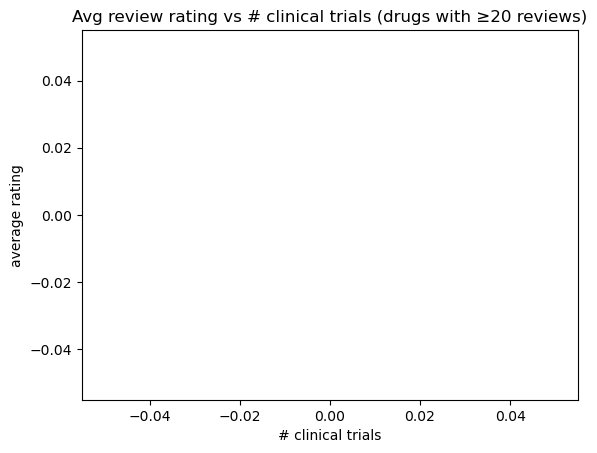

Pearson r: nan


In [48]:
# Plot only drugs with enough reviews for stability (say ≥20)
subset = drug_summary.query('n_reviews >= 20')

plt.figure()
plt.scatter(subset['n_trials'], subset['avg_rating'])
plt.title('Avg review rating vs # clinical trials (drugs with ≥20 reviews)')
plt.xlabel('# clinical trials')
plt.ylabel('average rating')
plt.show()

# Simple correlation
print("Pearson r:", subset[['n_trials','avg_rating']].corr().iloc[0,1])


In [24]:
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
_ = nltk.download('stopwords', quiet=True)
STOP = set(stopwords.words('english'))

def tokenize_simple(s):
    if pd.isna(s): return []
    toks = word_tokenize(str(s))
    return [t.lower() for t in toks if t.isalpha() and t.lower() not in STOP]

if 'sideEffectsReview' in rev:
    counts = Counter()
    rev['sideEffectsReview'].dropna().head(20000).apply(lambda s: counts.update(tokenize_simple(s)))
    print(counts.most_common(30))


[('side', 237), ('effects', 194), ('pain', 185), ('taking', 177), ('severe', 171), ('drug', 142), ('day', 142), ('could', 120), ('like', 117), ('would', 116), ('also', 116), ('felt', 108), ('time', 107), ('medication', 97), ('skin', 94), ('days', 89), ('weight', 85), ('take', 84), ('stomach', 82), ('first', 79), ('loss', 78), ('feeling', 75), ('sleep', 75), ('dry', 71), ('months', 69), ('even', 69), ('nausea', 69), ('took', 68), ('started', 67), ('became', 67)]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.7.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.7.1 when using version 1.5.1. This might lead to breaking code o

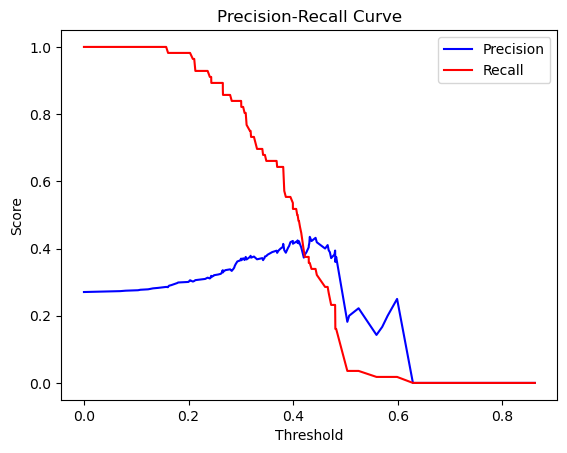

In [37]:
import pandas as pd
from joblib import load
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Load validation predictions data
df = pd.read_csv('outputs/validation_predictions.csv')

# Check for missing columns, and create them if necessary
if "rating" not in df.columns:
    if "y_true" in df.columns:
        df["rating"] = df["y_true"]  # Assuming 'y_true' corresponds to ratings
    else:
        raise ValueError("Column 'rating' or 'y_true' is required in the dataset.")

if "drug_name" not in df.columns:
    df["drug_name"] = "default_drug_name"  # If drug_name column is missing, add a placeholder

# Load the trained model
model = load('outputs/model_text_only.joblib')  # Path to your saved model

# Assuming 'X_valid' contains your validation dataset and 'text_all' is the text column
X_valid = df['text_all']  # Adjust the column name based on your data

# Predict probabilities for the positive class (class 1)
prob_text = model.predict_proba(X_valid)[:, 1]

# Assuming 'rating' is your true label for evaluation
y_true = df['rating'].values

# Plot Precision-Recall Curve
def plot_precision_recall_curve(y_true, y_prob):
    prec, rec, thresholds = precision_recall_curve(y_true, y_prob)
    plt.plot(thresholds, prec[:-1], label="Precision", color='blue')
    plt.plot(thresholds, rec[:-1], label="Recall", color='red')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

plot_precision_recall_curve(y_true, prob_text)


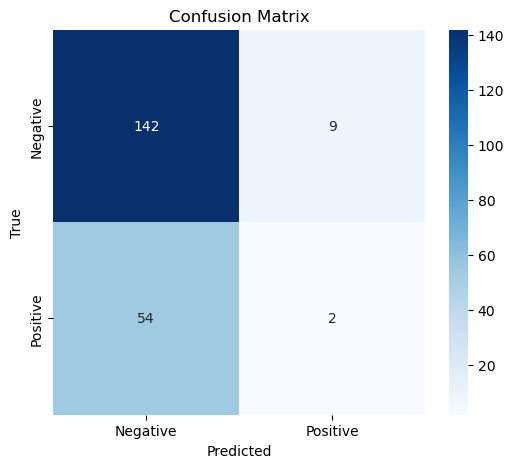

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_true, model.predict(X_valid))

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


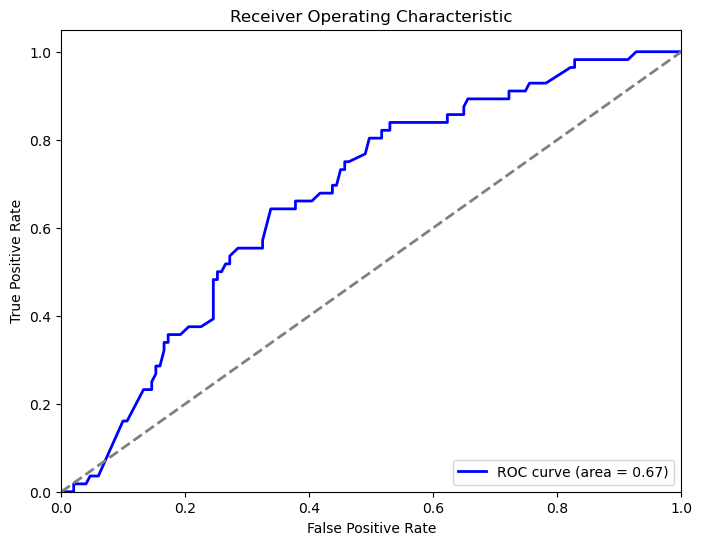

In [39]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_true, prob_text)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


In [42]:
import numpy as np

# Assuming you have a fitted model and it's a tree-based model or linear model
# For text model (e.g., Logistic Regression), we extract the coefficients

if hasattr(model, 'coef_'):
    coef = model.coef_.flatten()
    feature_names = model.named_steps['tfidfvectorizer'].get_feature_names_out()
    importance = np.abs(coef)

    # Create a DataFrame for sorting and plotting
    feature_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
    feature_df = feature_df.sort_values(by='importance', ascending=False).head(20)

    # Plot top 20 important features
    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=feature_df, palette='viridis')
    plt.title('Top 20 Important Features')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()


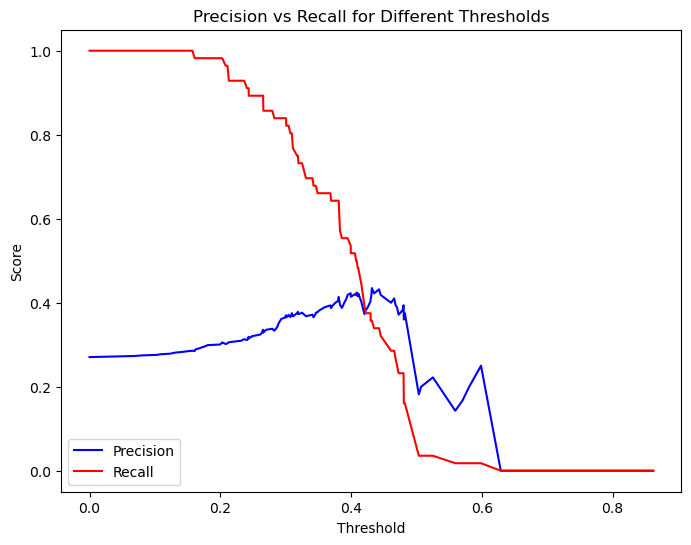

In [43]:
# Calculate precision and recall for multiple thresholds
prec, rec, thresholds = precision_recall_curve(y_true, prob_text)

# Plot precision vs recall for various thresholds
plt.figure(figsize=(8, 6))
plt.plot(thresholds, prec[:-1], label='Precision', color='blue')
plt.plot(thresholds, rec[:-1], label='Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall for Different Thresholds')
plt.legend(loc='lower left')
plt.show()


In [51]:
from sklearn.model_selection import learning_curve

# Ensure X_valid is a DataFrame and that 'text_all' exists
if 'text_all' not in X_valid.columns:
    X_valid['text_all'] = X_valid[['benefitsReview', 'sideEffectsReview', 'commentsReview']].fillna('').agg(' '.join, axis=1)

# Run the learning curve with error reporting
train_sizes, train_scores, test_scores = learning_curve(
    model, X_valid['text_all'], y_true, cv=5, error_score='raise'
)

# Calculate the mean and std deviation for train and test scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)
X_valid['text_all'] = X_valid['text_all'].fillna('')
y_true = y_true.fillna(0)  # Or handle missing target values appropriately

# Plot the learning curve
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, color='blue', label='Training score')
plt.plot(train_sizes, test_mean, color='red', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='red', alpha=0.2)
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.show()



Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 213, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 1954, in learning_curve
    results = parallel(
              ^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/parallel.py", line 74, in __call__
    return super().__call__(iterable_with_config)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/joblib/parallel.py", line 1918, in __call__
    return output if self.return_generator else list(output)
                                                ^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/joblib/parallel.py", line 1847, in _get_sequential_output
    res = func(*args, **kwargs)
          ^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib

/var/folders/j_/_3b07fdj35q3rrdgl_c7y3100000gn/T/ipykernel_15350/2062374725.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




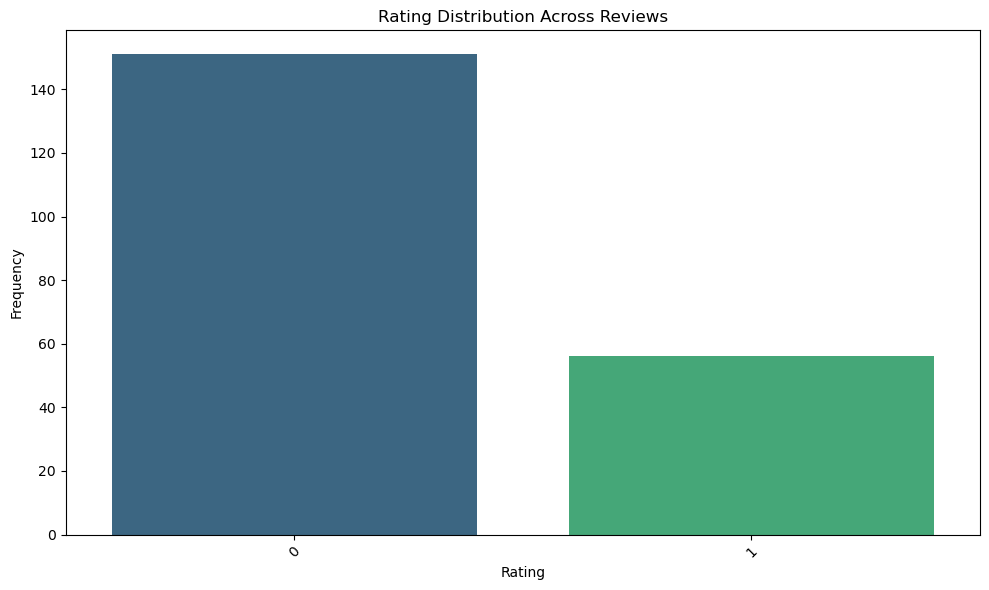

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming df is your DataFrame
df = pd.read_csv('outputs/validation_predictions.csv')

# Check and create missing columns
if "rating" not in df.columns:
    if "y_true" in df.columns:
        df["rating"] = df["y_true"]  # Assuming 'y_true' corresponds to ratings
    else:
        raise ValueError("Column 'rating' or 'y_true' is required.")

# Set up the plot
plt.figure(figsize=(10, 6))

# Use seaborn to plot the distribution of ratings
sns.countplot(data=df, x='rating', palette='viridis')

plt.title('Rating Distribution Across Reviews')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [53]:
import plotly.graph_objects as go
from sklearn.metrics import precision_recall_curve

# Assuming 'model' is your trained model and 'X_valid' is your validation data
prob_text = model.predict_proba(X_valid['text_all'])[:, 1]
precision, recall, thresholds = precision_recall_curve(y_true, prob_text)

# Create the plot
fig = go.Figure()

fig.add_trace(go.Scatter(x=thresholds, y=precision[:-1], mode='lines', name='Precision', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=thresholds, y=recall[:-1], mode='lines', name='Recall', line=dict(color='red')))

fig.update_layout(
    title='Precision-Recall Curve',
    xaxis_title='Threshold',
    yaxis_title='Score',
    legend_title='Metrics',
    template='plotly_dark'
)

fig.show()



In [57]:
import plotly.graph_objects as go
from sklearn.metrics import precision_recall_curve

# Assuming 'model' is your trained model and 'X_valid' contains the features
prob_text = model.predict_proba(X_valid['text_all'])[:, 1]
precision, recall, thresholds = precision_recall_curve(y_true, prob_text)

# Create interactive precision-recall curve
fig = go.Figure()

fig.add_trace(go.Scatter(x=thresholds, y=precision[:-1], mode='lines', name='Precision', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=thresholds, y=recall[:-1], mode='lines', name='Recall', line=dict(color='red')))

fig.update_layout(
    title='Interactive Precision-Recall Curve',
    xaxis_title='Threshold',
    yaxis_title='Score',
    legend_title='Metrics',
    template='plotly_dark'
)

fig.show()


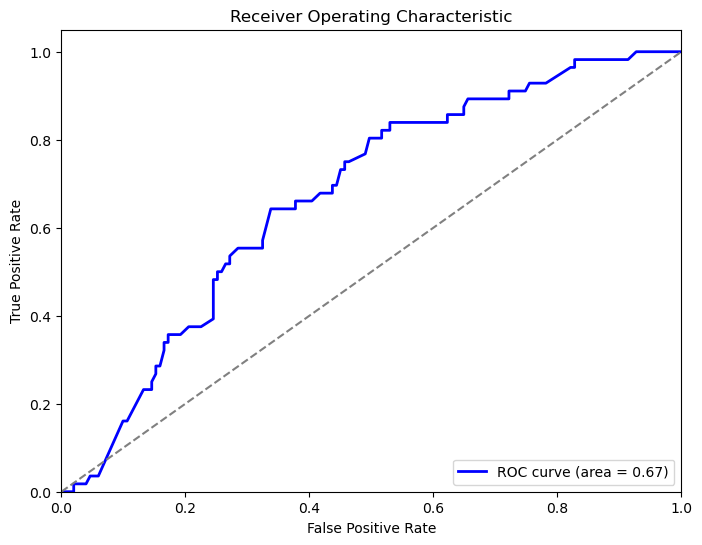

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming 'y_true' and 'y_pred_prob' are the true labels and predicted probabilities
fpr, tpr, thresholds = roc_curve(y_true, prob_text)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning:

Trying to unpickle estimator TfidfVectorizer from version 1.7.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning:

Trying to unpickle estimator LinearSVC from version 1.7.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning:

Trying to unpickle estimator Pipeline from version 1.7.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at you

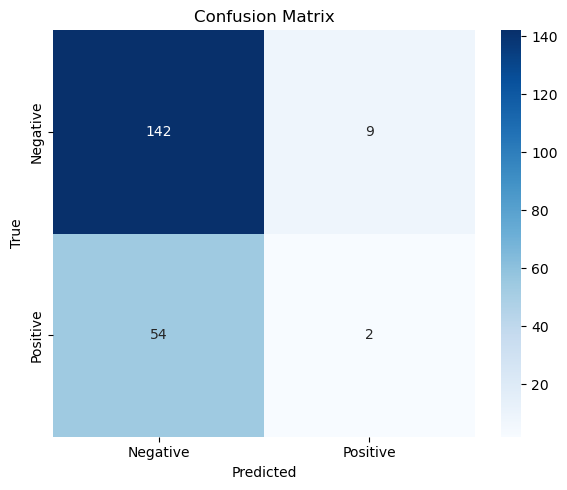

In [62]:
import pandas as pd
from joblib import load
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load validation predictions data
df = pd.read_csv('outputs/validation_predictions.csv')

# Check for missing columns, and create them if necessary
if "rating" not in df.columns:
    if "y_true" in df.columns:
        df["rating"] = df["y_true"]  # Assuming 'y_true' corresponds to ratings
    else:
        raise ValueError("Column 'rating' or 'y_true' is required in the dataset.")

if "drug_name" not in df.columns:
    df["drug_name"] = "default_drug_name"  # If drug_name column is missing, add a placeholder

# Load the trained model (ensure scikit-learn versions match)
model = load('outputs/model_text_only.joblib')  # Adjust with your model path

# Assuming 'X_valid' contains your validation dataset and 'text_all' is the text column
X_valid = df['text_all']  # Adjust the column name based on your data

# Predict probabilities for the positive class (class 1)
y_true = df['rating']
y_pred = model.predict(X_valid)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()


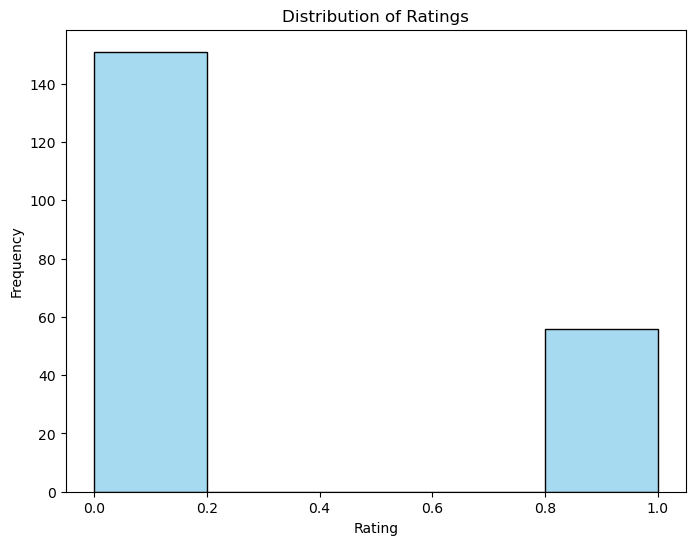

In [63]:
import seaborn as sns

# Plot the distribution of ratings
plt.figure(figsize=(8, 6))
sns.histplot(df['rating'], kde=False, bins=5, color='skyblue', edgecolor='black')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()


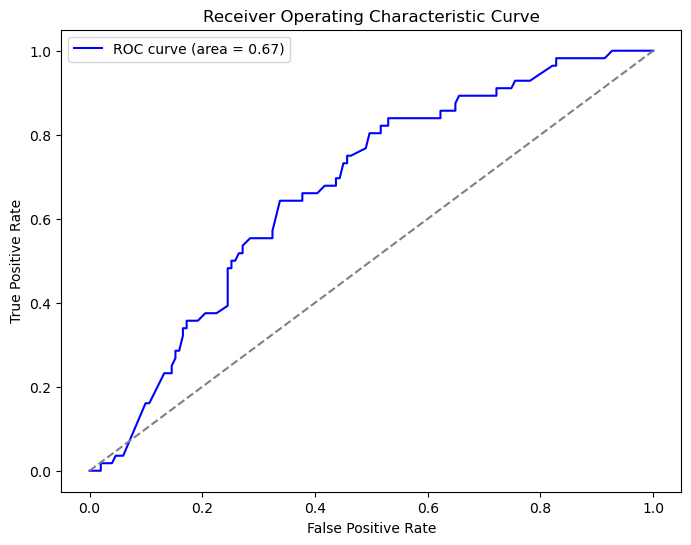

In [64]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, model.predict_proba(X_valid)[:,1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc='best')
plt.show()


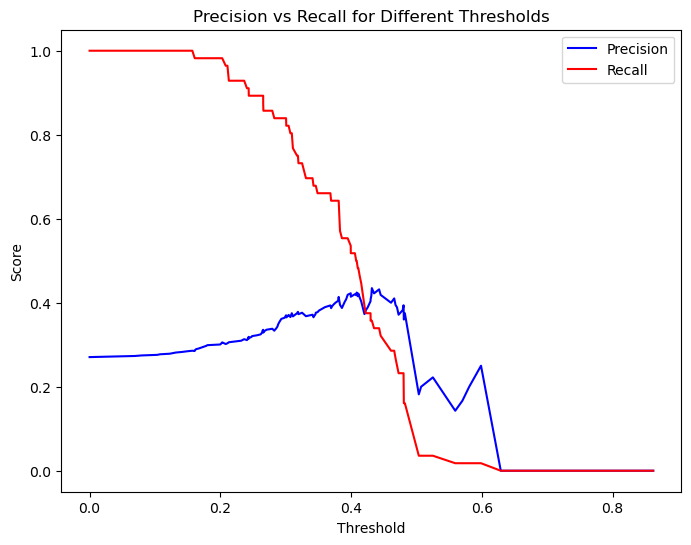

In [65]:
# Plot Precision vs Recall vs Threshold
prec, rec, thresholds = precision_recall_curve(y_true, model.predict_proba(X_valid)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(thresholds, prec[:-1], label="Precision", color='blue')
plt.plot(thresholds, rec[:-1], label="Recall", color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall for Different Thresholds')
plt.legend()
plt.show()


In [66]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(model, X_valid['text_all'], y_true, cv=5)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_std = test_scores.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, color='blue', label='Training score')
plt.plot(train_sizes, test_mean, color='red', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='red', alpha=0.2)
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Learning Curve')
plt.legend(loc='best')
plt.show()



Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3579, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/j_/_3b07fdj35q3rrdgl_c7y3100000gn/T/ipykernel_15350/1060729616.py", line 3, in <module>
    train_sizes, train_scores, test_scores = learning_curve(model, X_valid['text_all'], y_true, cv=5)
                                                                   ~~~~~~~^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/pandas/core/series.py", line 1130, in __getitem__
    return self._get_value(key)
           ^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/pandas/core/series.py", line 1246, in _get_value
    loc = self.index.get_loc(label)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/pandas/core/indexes/range.py", line 417, in get_loc
    raise KeyError(key)
KeyError: 'text_all'

During handlin

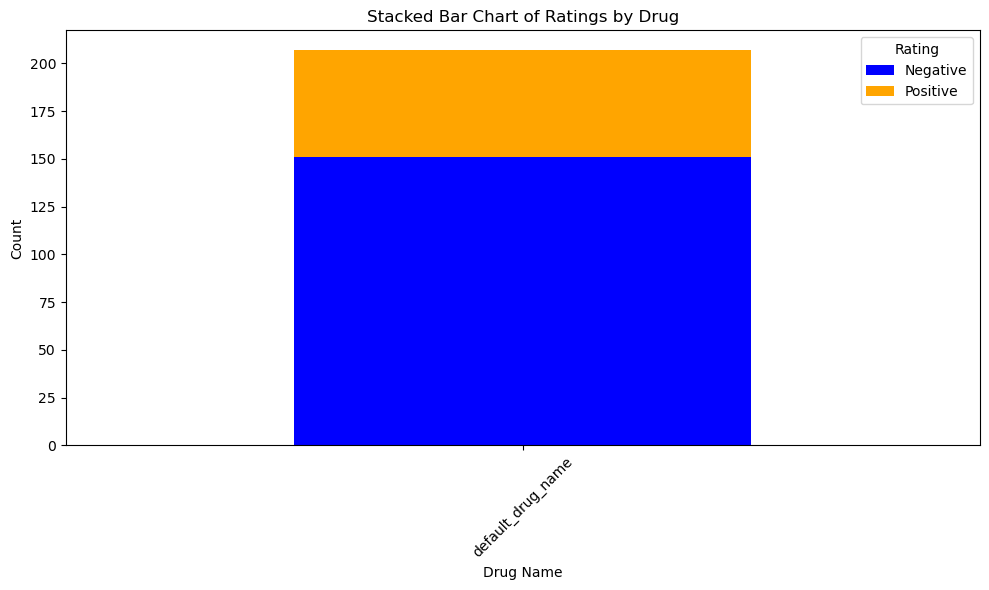

In [67]:
import matplotlib.pyplot as plt

# Create a stacked bar chart of ratings by drug
rating_by_drug = df.groupby(['drug_name', 'rating']).size().unstack(fill_value=0)

rating_by_drug.plot(kind='bar', stacked=True, figsize=(10, 6), color=['blue', 'orange'])
plt.title('Stacked Bar Chart of Ratings by Drug')
plt.xlabel('Drug Name')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Rating', labels=['Negative', 'Positive'])
plt.tight_layout()
plt.show()


In [68]:
import numpy as np

# Assuming you are using a model with feature importance like a Random Forest
# If you're using a different model, modify accordingly
feature_importances = model.feature_importances_

# Plotting the feature importances
plt.figure(figsize=(10, 6))
plt.barh(df.columns, feature_importances, color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance of Model')
plt.tight_layout()
plt.show()


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3579, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/j_/_3b07fdj35q3rrdgl_c7y3100000gn/T/ipykernel_15350/3628778027.py", line 5, in <module>
    feature_importances = model.feature_importances_
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'CalibratedClassifierCV' object has no attribute 'feature_importances_'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 2170, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/IPython/core/ultratb.py", line 1457, in structured_traceback
    return FormattedTB.structured_traceback(
           ^^^^^^^

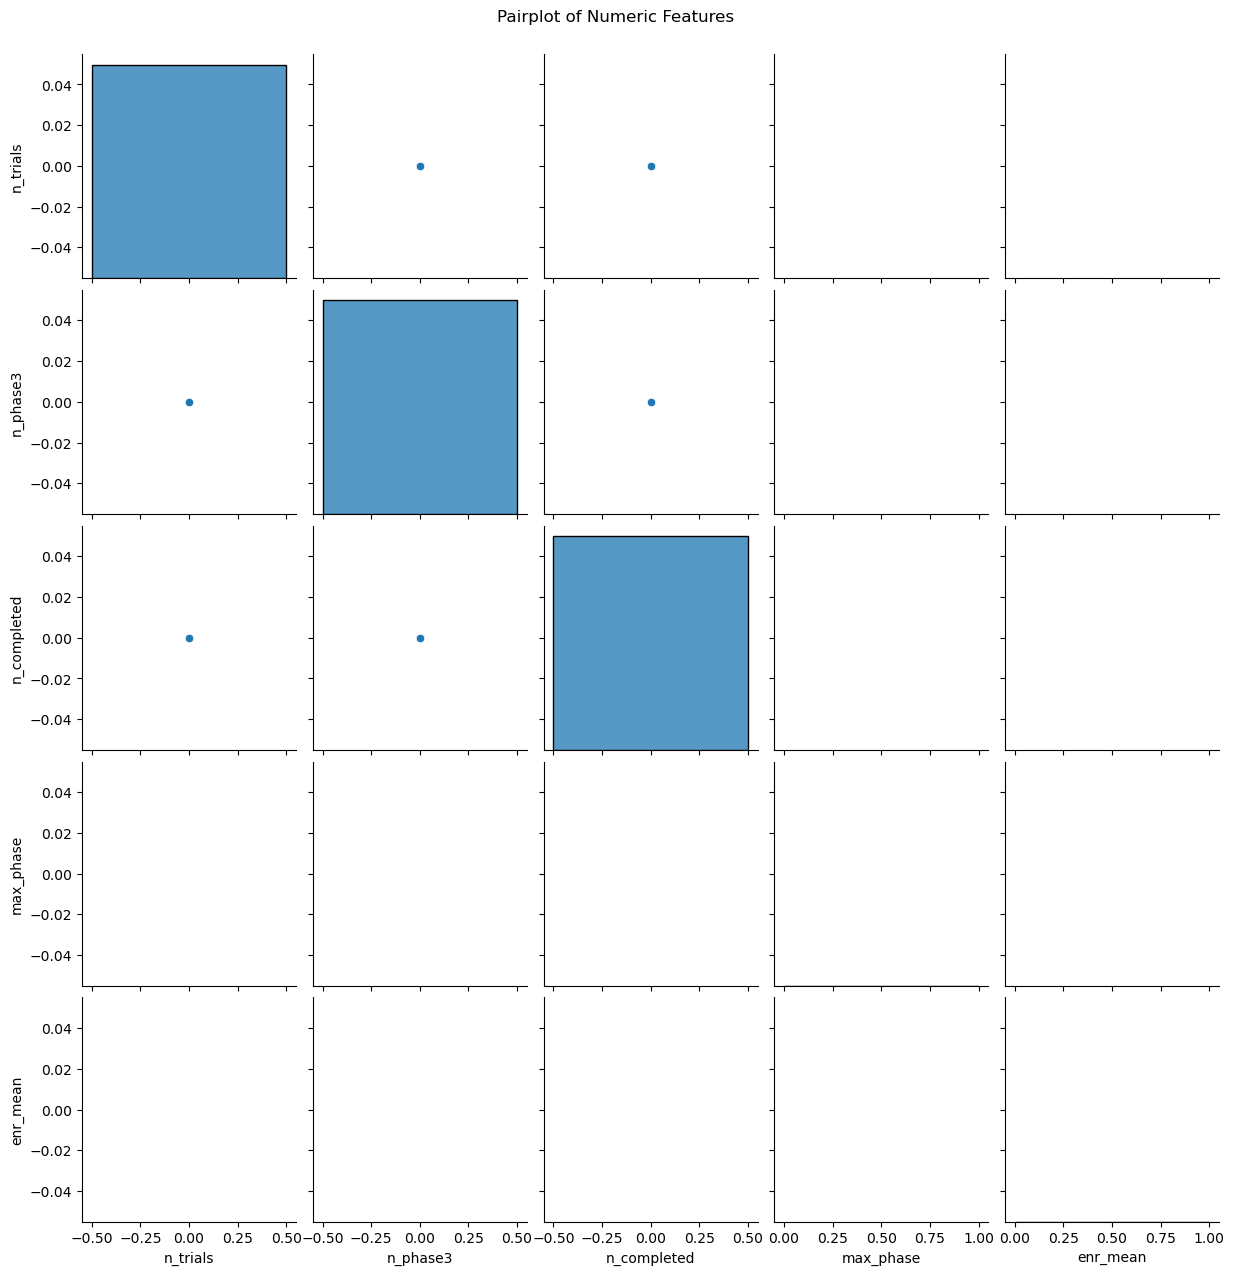

In [69]:
sns.pairplot(df[['n_trials', 'n_phase3', 'n_completed', 'max_phase', 'enr_mean']])
plt.suptitle("Pairplot of Numeric Features", y=1.02)
plt.show()



/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning:

All-NaN slice encountered

/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning:

All-NaN slice encountered



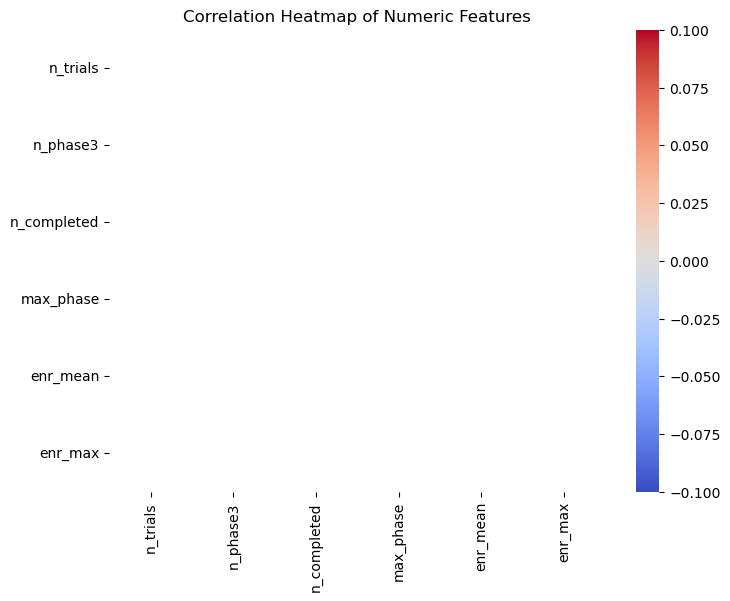

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr_matrix = df[['n_trials', 'n_phase3', 'n_completed', 'max_phase', 'enr_mean', 'enr_max']].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()
